In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import requests
import numpy as np

import sys
from pathlib import Path

# notebook is in notebooks/, so go up one level to repo root, then into src
sys.path.insert(0, str(Path("..").resolve()))

from src.meteo.province import ProvinceMeteo

In [130]:
start_date = pd.Timestamp("2025-01-01", tz = 'UTC')
end_date = pd.Timestamp("2026-03-01", tz = 'UTC')
reference_station = '09700MS'

province_handler = ProvinceMeteo(timezone = 'Europe/Rome')

lat = 46.623755
lon = 10.78027
models = ['meteoswiss_icon_seamless', 'best_match', "meteofrance_seamless","knmi_seamless","italia_meteo_arpae_icon_2i","icon_seamless"]
day_offset = 2
previous_runs_url_template = "https://previous-runs-api.open-meteo.com/v1/forecast?latitude={lat}&longitude={lon}&hourly=shortwave_radiation_previous_day{day_offset}&models={models}&start_date={start_date:%Y-%m-%d}&end_date={end_date:%Y-%m-%d}"

Load data from the reference province station

In [ ]:
async def get_observed_data():
    async with province_handler as prv:
        observed_data = await prv.run(
            start = start_date,
            end = end_date,
            station_id = reference_station
        )
    
    observed_data = observed_data[['datetime', 'model', 'station_id', 'solar_radiation']].copy()

    observed_data = (
        observed_data
        .set_index('datetime')
        .groupby(['model', 'station_id'])
        .resample('h', label='right', closed='right') #because open-meteo uses average of previous hours so timestamps align
        .mean()
        .reset_index()
    )
    
    # keep alignment with forecast range after shifting
    observed_data = observed_data[(observed_data['datetime'] >= start_date) & (observed_data['datetime'] <= end_date)]
    
    return observed_data[['datetime', 'model', 'station_id', 'solar_radiation']]

observed_data = await get_observed_data()

In [132]:
observed_data.head()

sensor,datetime,model,station_id,solar_radiation
1,2025-01-01 00:00:00+00:00,observation,09700MS,0.0
2,2025-01-01 01:00:00+00:00,observation,09700MS,0.0
3,2025-01-01 02:00:00+00:00,observation,09700MS,0.0
4,2025-01-01 03:00:00+00:00,observation,09700MS,0.0
5,2025-01-01 04:00:00+00:00,observation,09700MS,0.0


Load forecast data

In [133]:
def get_forecast_data():

    forecast_data = []
    for model in models:
        request_url = previous_runs_url_template.format(
            lat = lat, lon = lon, models = model, day_offset = day_offset, start_date = start_date, end_date = end_date
        )
        response = requests.get(request_url)
        response.raise_for_status()

        _forecast_data = pd.DataFrame(response.json()['hourly'])
        _forecast_data['time'] = pd.to_datetime(_forecast_data['time'], utc = True)
        _forecast_data.rename(columns = {'time': 'datetime', f'shortwave_radiation_previous_day{day_offset}': 'solar_radiation'}, inplace = True)
        _forecast_data['model'] = model

        forecast_data.append(_forecast_data[['datetime', 'model', 'solar_radiation']])

    return pd.concat(forecast_data, ignore_index = True)

forecast_data = get_forecast_data()

In [134]:
radiation_tbl = pd.concat([observed_data, forecast_data])
radiation_tbl = radiation_tbl.pivot(columns = 'model', values = 'solar_radiation', index = 'datetime')

radiation_tbl['month'] = radiation_tbl.index.month
radiation_tbl['hour'] = radiation_tbl.index.hour

In [135]:
error_tbl = radiation_tbl.sub(radiation_tbl['observation'], axis = 0)
error_tbl['month'] = error_tbl.index.month
error_tbl['hour'] = error_tbl.index.hour

<Axes: xlabel='hour'>

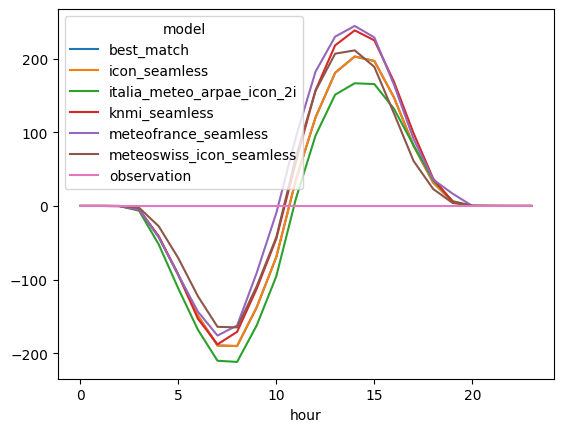

In [136]:
error_tbl.groupby('hour').mean().drop(columns = ['month']).plot()

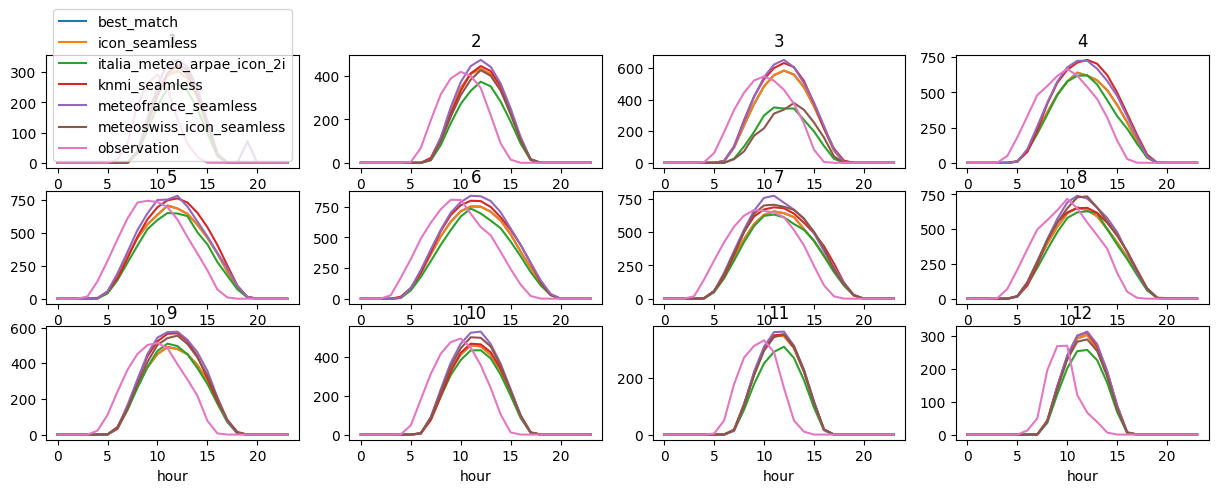

In [137]:
nmonths = len(radiation_tbl['month'].unique())
ncols = min(nmonths, 4)
nrows = (nmonths + ncols - 1) // ncols

fig, axs = plt.subplots(ncols = ncols, nrows = nrows, figsize = (15, 5))
axs = np.atleast_1d(axs).ravel()

for (month, data), ax in zip(radiation_tbl.groupby('month'), axs):
    data.drop(columns=['month']).groupby(['hour']).mean().plot(ax = ax, legend = False)
    ax.set_title(month)

    if month == radiation_tbl['month'].min():
        ax.legend()

for ax in axs[nmonths:]:
    ax.set_visible(False)